In [2]:
import os
import pandas as pd
from tensorboard.backend.event_processing import event_accumulator
import matplotlib.pyplot as plt
import numpy as np
import scienceplots
import glob
import re
from pathlib import Path
import ast
import matplotlib.ticker as ticker
from statsmodels.stats.proportion import proportion_confint


In [2]:
def tflog2pandas(path, filter_tags=None):
    runlog_data = pd.DataFrame()
    ea = event_accumulator.EventAccumulator(path, size_guidance={"scalars": 0})
    ea.Reload()

    tags = ea.Tags()["scalars"]

    for tag in tags:
        if filter_tags is not None and tag not in filter_tags:
            continue
        event_list = ea.Scalars(tag)
        values = [e.value for e in event_list]
        steps = [e.step for e in event_list]
        tag_df = pd.DataFrame({tag: values, "step": steps})
        
        if runlog_data.empty:
            runlog_data = tag_df
        else:
            runlog_data = pd.merge(runlog_data, tag_df, on="step", how="outer")

    return runlog_data


In [60]:
dftrain = tflog2pandas("./runs/supervised/final_model/train", ["Loss"])
dfvalidation = tflog2pandas("./runs/supervised/final_model/validation", ["Loss"])

In [29]:
plt.style.use("science")

In [2]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
})

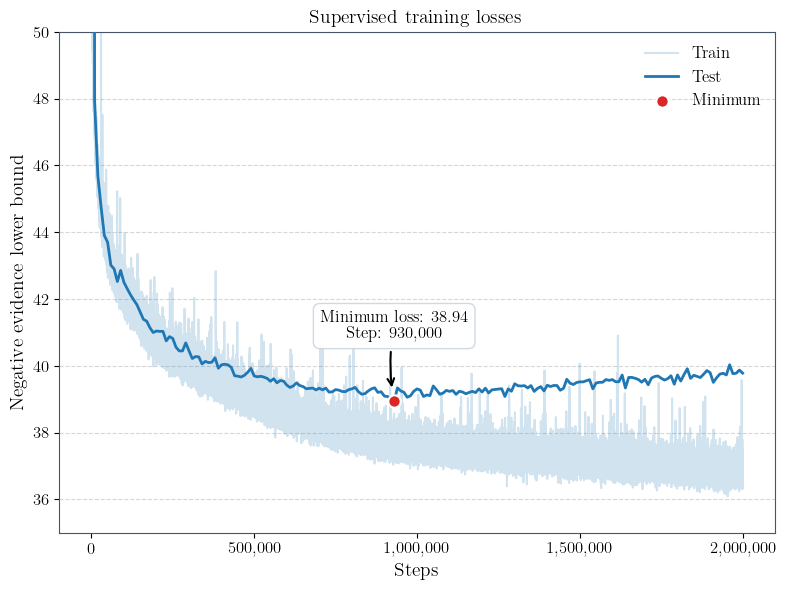

In [ ]:
min_loss_idx = dfvalidation["Loss"].idxmin()
min_step = dfvalidation.loc[min_loss_idx, "step"]
min_loss = dfvalidation.loc[min_loss_idx, "Loss"]

plt.figure(figsize=(8, 6))

# 1. Mute the Training Line 
plt.plot(dftrain["step"], dftrain["Loss"], 
         label="Train", 
         color="tab:blue",
         alpha=0.2,
         linewidth=1.5, 
        )

# 2. Emphasize the Validation/Test Line 
plt.plot(dfvalidation["step"], dfvalidation["Loss"], 
         label="Test", 
         color="tab:blue", 
        #  linewidth=2.5,
         linewidth=2,
         zorder=4)

# 3. Style the Minimum Point 
plt.scatter(min_step, min_loss, 
            color="#DC2626", 
            s=80, 
            edgecolors="white", 
            linewidths=1.5, 
            zorder=5, 
            label="Minimum")

# 4. Clean up the Annotation 
plt.annotate(
    f"Minimum loss: {min_loss:.2f}\nStep: {min_step:,.0f}", 
    xy=(min_step, min_loss), 
    xytext=(0, 45), 
    textcoords="offset points",
    arrowprops=dict(
        arrowstyle="->", 
        color="black", 
        lw=1.5,
        connectionstyle="arc3,rad=0.1",
        shrinkB=10  # <--- THIS IS THE FIX: pulls the arrow tip away from the dot
    ),
    fontsize=12,
    ha="center",
    bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="#CBD5E1", alpha=0.9)
)

# --- Formatting ---
plt.ylim((35, 50))
plt.xlabel("Steps", fontsize=14)
plt.ylabel("Negative evidence lower bound", fontsize=14)
plt.title("Supervised training losses", fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Legend adjustments
plt.legend(fontsize=12, frameon=False)

# Grid and Spines
ax = plt.gca()
ax.spines["top"].set_color("#475569")
ax.spines["right"].set_color("#475569")
ax.spines["left"].set_color("#475569")
ax.spines["bottom"].set_color("#475569")

# X-axis ticker formatting
ax.xaxis.set_major_locator(ticker.MultipleLocator(500_000))
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# Grid
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
# plt.savefig(f"../Thesis/sections/figures/supervised_training_progress/Training_loss.pdf")
plt.show()


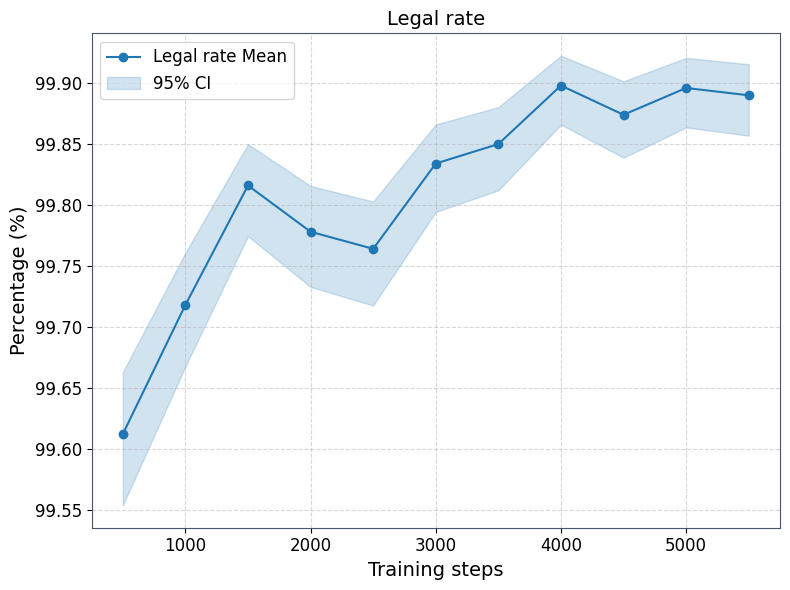

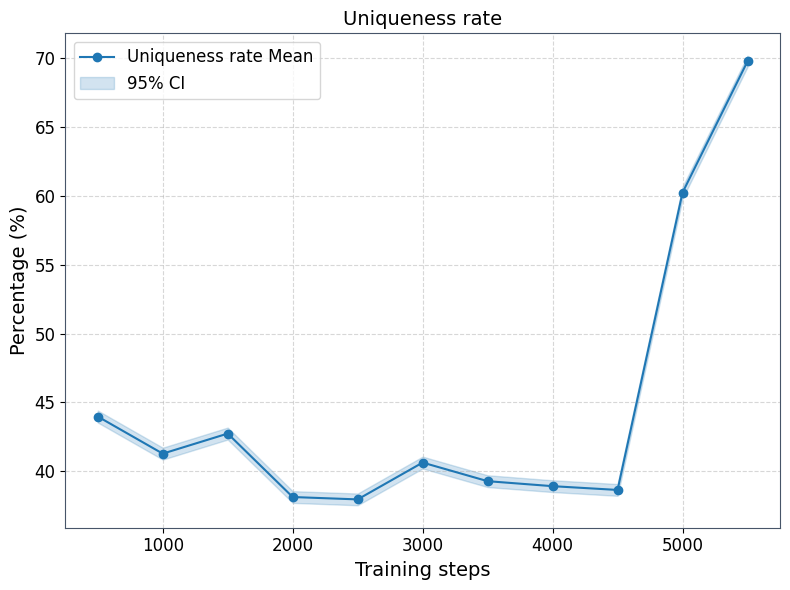

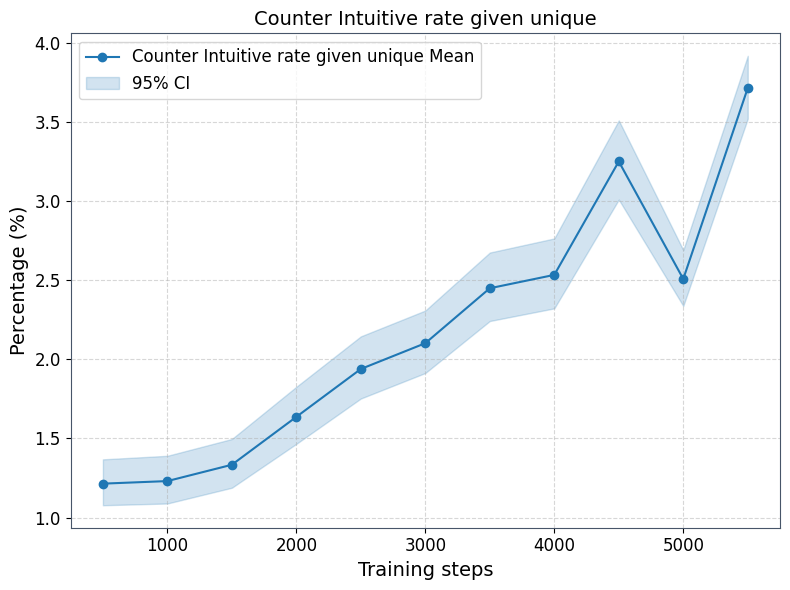

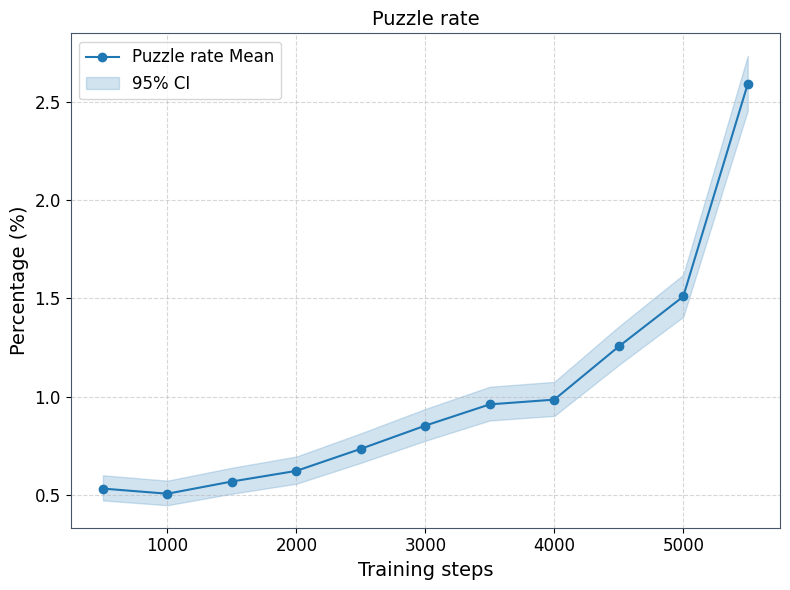

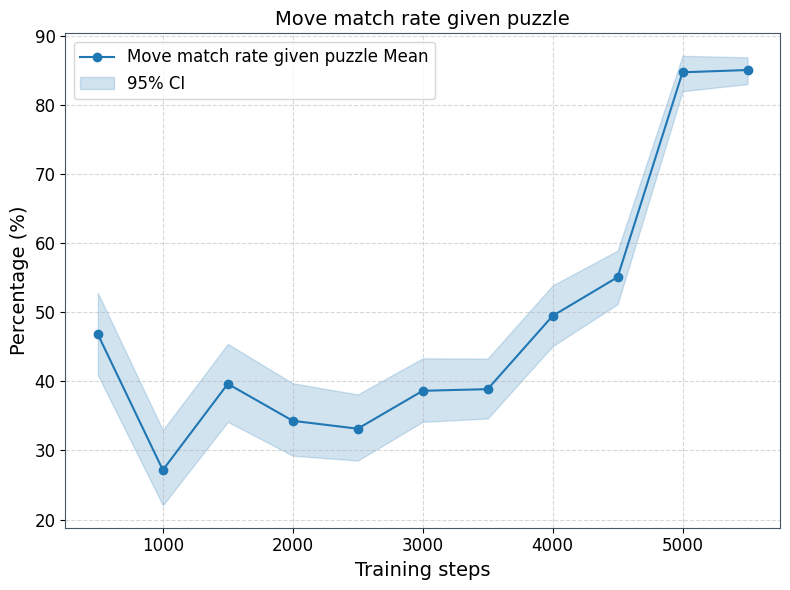

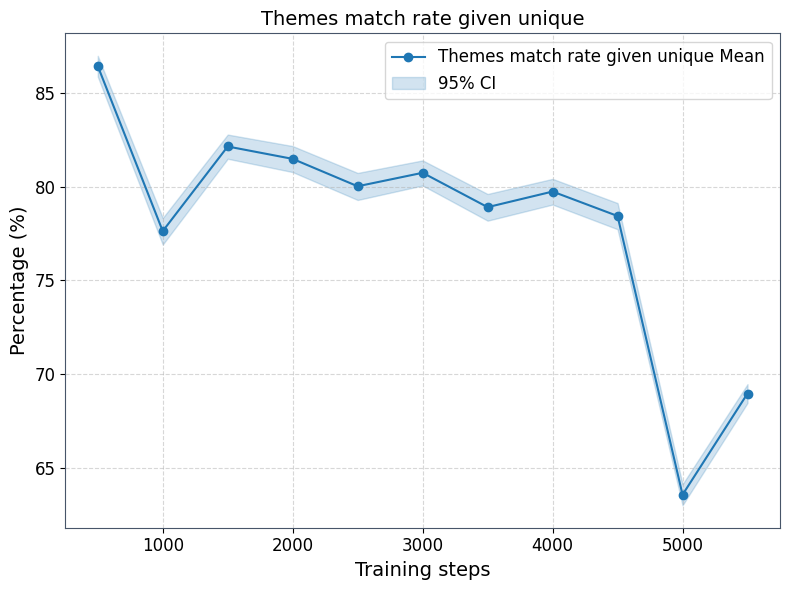

In [ ]:
folder_path = "Generate_positions/final_model/rl/training_progress/test_no_move_lastv2"
needed_columns = ["is_legal", "is_puzzle_true", "counter_intuitive_true", "themes_match", "best_move", "main_line"]
file_pattern = os.path.join(folder_path, 'model_*.csv')
file_paths = sorted(glob.glob(file_pattern), key=lambda f: int(re.search(r'model_(\d+)\.csv', f).group(1)))

data_points = []
for file in file_paths:
    model_number = int(re.search(r'model_(\d+)\.csv', os.path.basename(file)).group(1))
    df = pd.read_csv(file, usecols=needed_columns)
    
    # Define dataset subsets
    n_total = len(df)
    unique_positions = df[df["is_puzzle_true"]]
    unique_and_counter_intuitive = df[df["is_puzzle_true"] & df["counter_intuitive_true"]]
    
    # Store both count and the specific 'n' for each metric
    row = {
        "model_number": model_number,
        "Legal rate": {
            "count": df["is_legal"].sum(), 
            "n": n_total
        },
        "Uniqueness rate": {
            "count": df["is_puzzle_true"].sum(), 
            "n": n_total
        },
        "Counter Intuitive rate given unique": {
            "count": unique_positions["counter_intuitive_true"].sum(), 
            "n": len(unique_positions)
        },
        "Puzzle rate": {
            "count": (df["is_puzzle_true"] & df["counter_intuitive_true"]).sum(), 
            "n": n_total
        },
        "Move match rate given puzzle": {
            "count": (unique_and_counter_intuitive["main_line"].str.split(" ").str[0] == unique_and_counter_intuitive["best_move"]).sum(), 
            "n": len(unique_and_counter_intuitive)
        },
        "Themes match rate given unique": {
            "count": df[~pd.isna(df["themes_match"])]["themes_match"].sum(),
            "n": (~pd.isna(df["themes_match"])).sum()
        }
    }
    data_points.append(row)

# Convert to DataFrame
df_results = pd.DataFrame(data_points)

# 2. Plotting with Uncertainty
metrics = [
    "Legal rate", 
    "Uniqueness rate", 
    "Counter Intuitive rate given unique", 
    "Puzzle rate", 
    "Move match rate given puzzle",
    "Themes match rate given unique"
]

for metric in metrics:
    plt.figure(figsize=(8, 6))
    
    x = df_results["model_number"]
    counts = np.array([d["count"] for d in df_results[metric]])
    n_vals = np.array([d["n"] for d in df_results[metric]])    
    means = 100 * counts / n_vals
    
    low = np.zeros_like(means)
    high = np.zeros_like(means)
    
    low, high = proportion_confint(counts, n_vals, alpha=0.05, method="wilson")
    
    # Plotting
    plt.plot(x, means, marker="o", linestyle="-", label=f"{metric} Mean", c="tab:blue")
    plt.fill_between(x, low * 100, high * 100, color="tab:blue", alpha=0.2, label="95% CI")
    
    plt.xlabel("Training steps", fontsize=14)
    plt.ylabel("Percentage (%)", fontsize=14)
    plt.title(metric, fontsize=14)

    ax = plt.gca()
    ax.spines["top"].set_color("#475569")
    ax.spines["right"].set_color("#475569")
    ax.spines["left"].set_color("#475569")
    ax.spines["bottom"].set_color("#475569")
    # ax.xaxis.set_major_locator(ticker.MultipleLocator(1_000))
    # ax.ticklabel_format(style="plain", axis="x")
    # ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)

    plt.legend(fontsize=12)
    plt.grid(which="both", linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

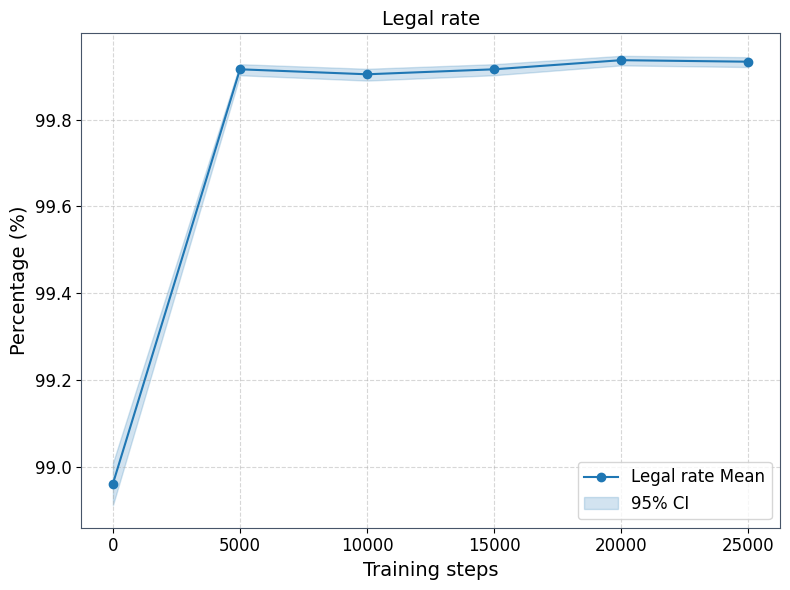

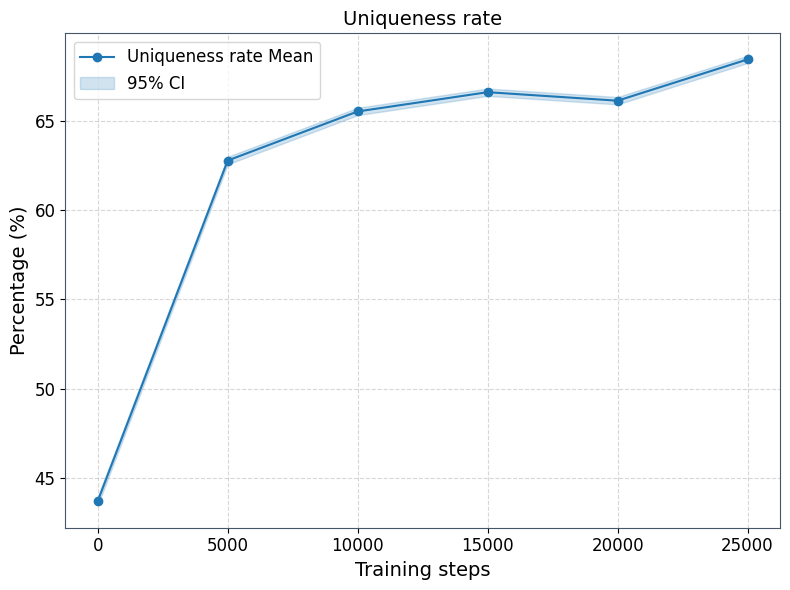

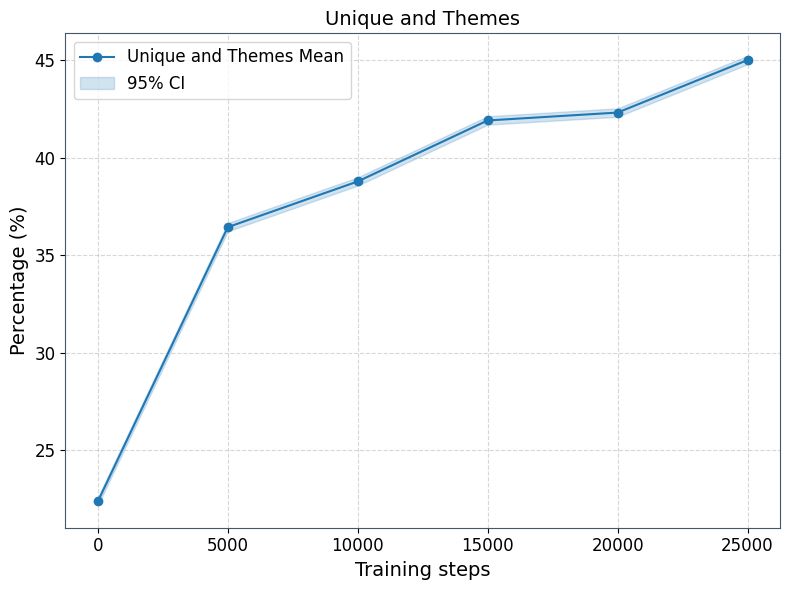

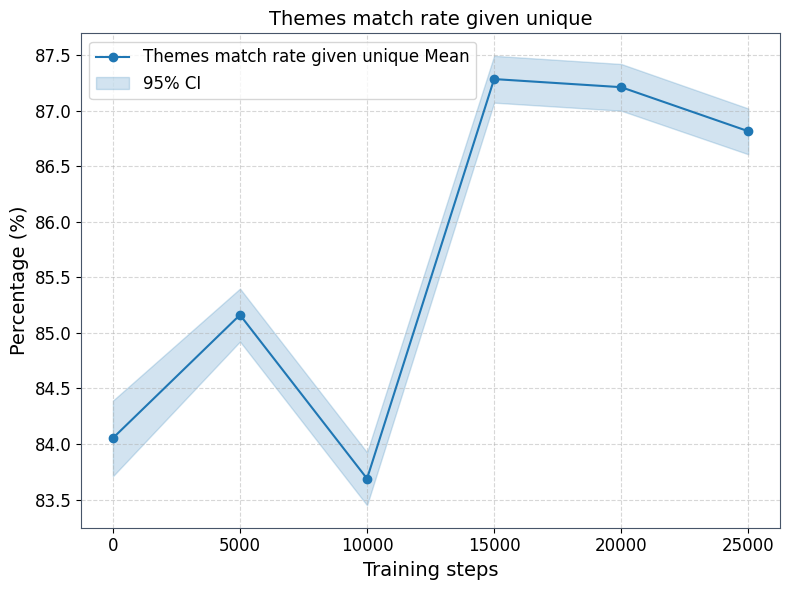

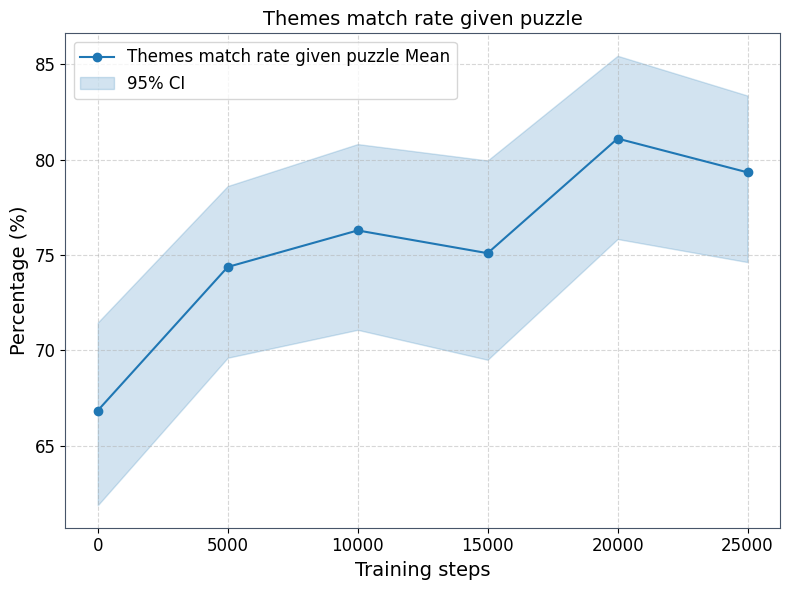

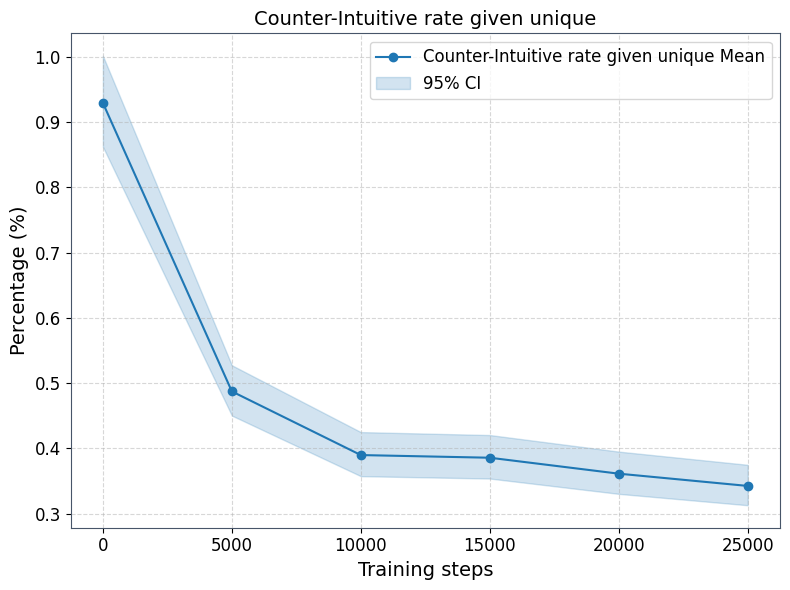

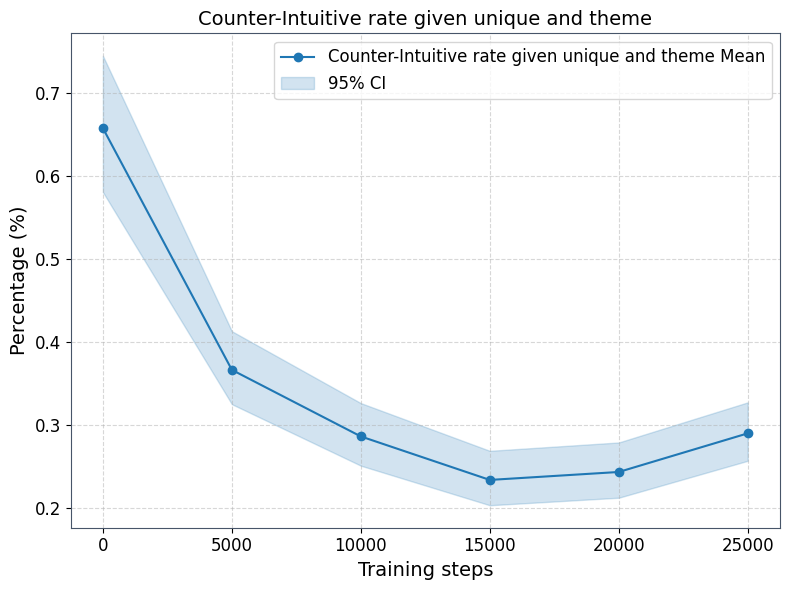

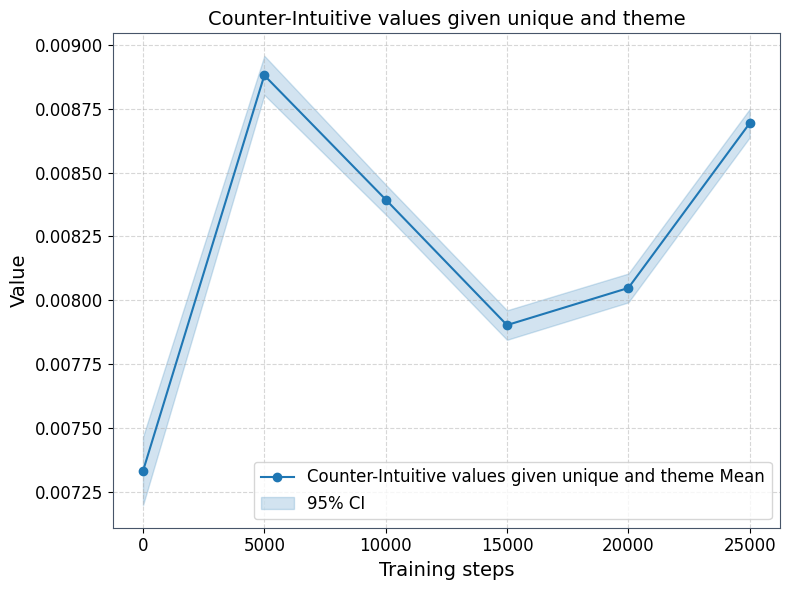

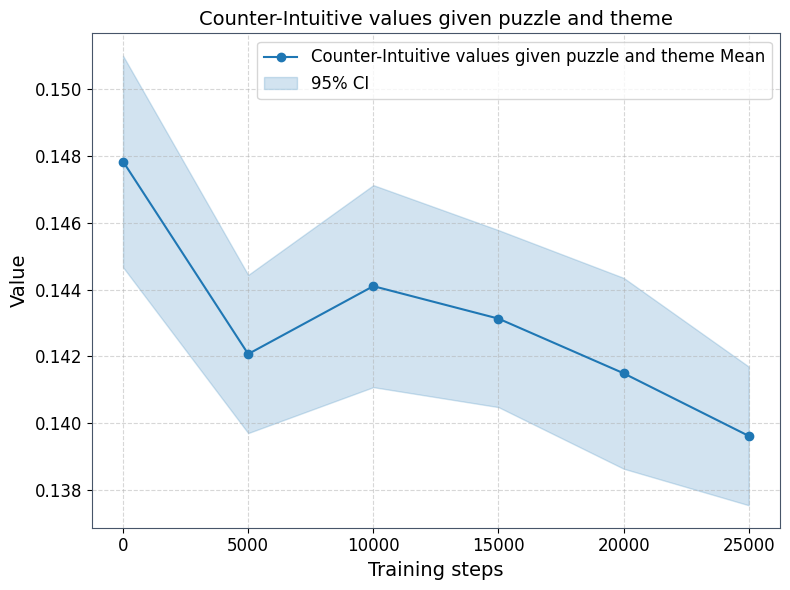

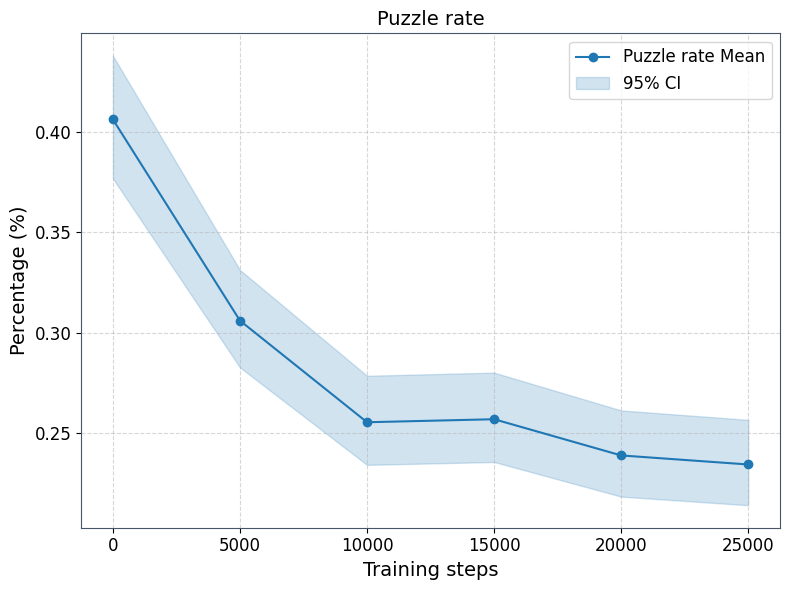

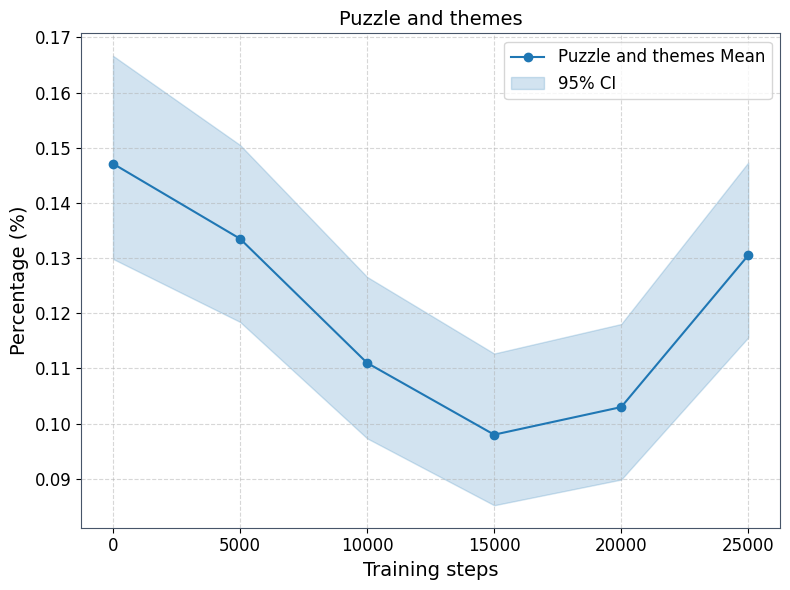

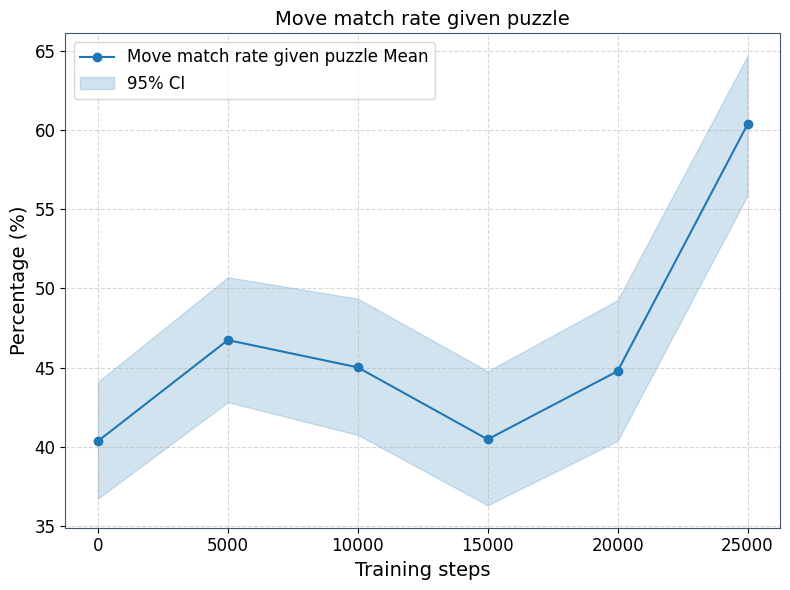

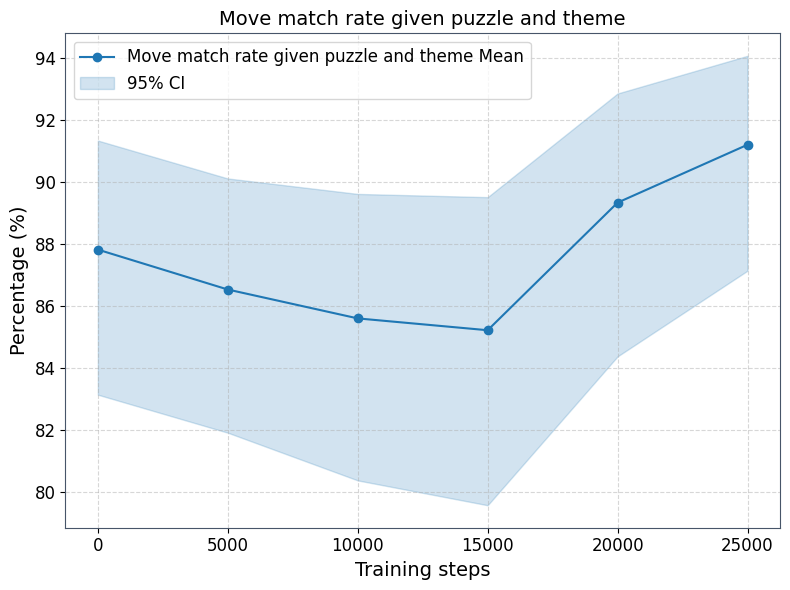

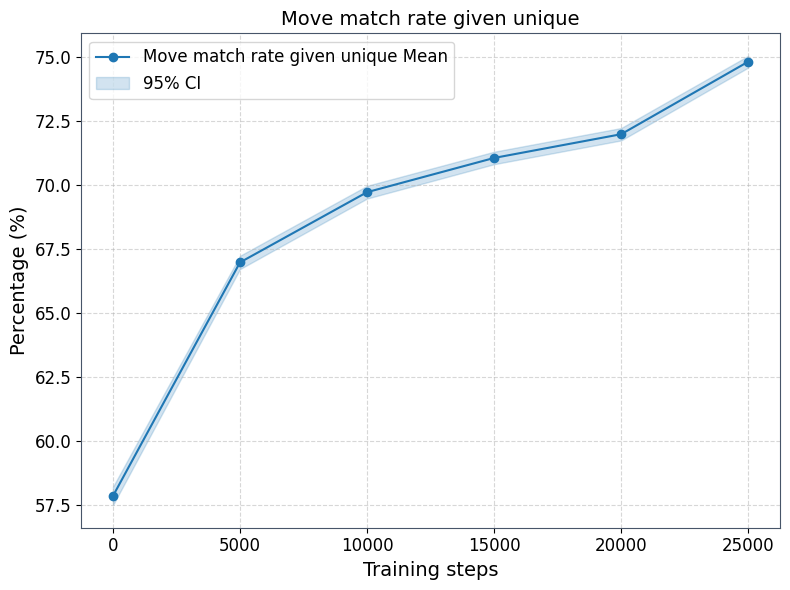

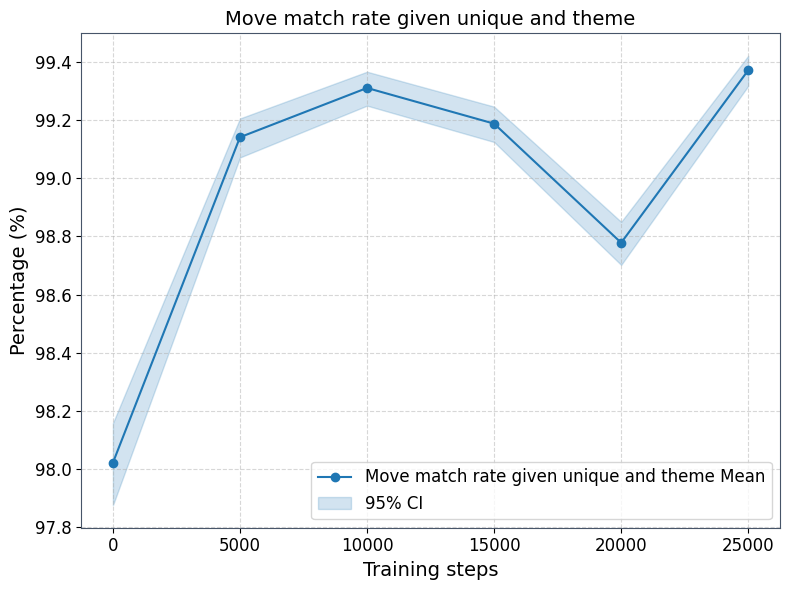

In [32]:
folder_path = "Generate_positions/arxiv_true/run22"
needed_columns = ["is_legal", "is_puzzle", "counter_intuitive", "counter_intuitive_value", "themes_match", "best_move", "main_line"]
file_pattern = os.path.join(folder_path, 'model_*.csv')
file_paths = sorted(glob.glob(file_pattern), key=lambda f: int(re.search(r'model_(\d+)\.csv', f).group(1)))

data_points = []
for file in file_paths:
    model_number = int(re.search(r'model_(\d+)\.csv', os.path.basename(file)).group(1))
    df = pd.read_csv(file, usecols=needed_columns)
    
    n_total = len(df)
    unique_positions = df[df["is_puzzle"]]
    unique_and_themes = df[df["is_puzzle"] & df["themes_match"]]
    unique_and_counter_intuitive = df[df["is_puzzle"] & df["counter_intuitive"]]
    unique_and_counter_intuitive_and_themes = df[df["is_puzzle"] & df["counter_intuitive"] & df["themes_match"]]
    
    row = {
        "model_number": model_number,
        "Legal rate": {
            "count": df["is_legal"].sum(), 
            "n": n_total
        },
        "Uniqueness rate": {
            "count": df["is_puzzle"].sum(), 
            "n": n_total
        },
        "Unique and Themes": {
            "count": (df["is_puzzle"] & df["themes_match"]).sum(), 
            "n": n_total
        },
        "Themes match rate given unique": {
            "count": df[~pd.isna(df["themes_match"])]["themes_match"].sum(),
            "n": len(df[~pd.isna(df["themes_match"])]["themes_match"])
        },
        "Themes match rate given puzzle": {
            "count": df[~pd.isna(df["themes_match"]) & df["counter_intuitive"]]["themes_match"].sum(),
            "n": len(df[~pd.isna(df["themes_match"]) & df["counter_intuitive"]]["themes_match"])
        },
        "Counter-Intuitive rate given unique": {
            "count": unique_positions["counter_intuitive"].sum(), 
            "n": len(unique_positions)
        },
        "Counter-Intuitive rate given unique and theme": {
            "count": unique_and_themes["counter_intuitive"].sum(), 
            "n": len(unique_and_themes)
        },
        "Counter-Intuitive values given unique and theme": {
            "mean": unique_and_themes["counter_intuitive_value"].mean(),
            "standard error": unique_and_themes["counter_intuitive_value"].sem()
        },
        "Counter-Intuitive values given puzzle and theme": {
            "mean": unique_and_counter_intuitive_and_themes["counter_intuitive_value"].mean(),
            "standard error": unique_and_counter_intuitive_and_themes["counter_intuitive_value"].sem()
        },
        "Puzzle rate": {
            "count": (df["is_puzzle"] & df["counter_intuitive"]).sum(), 
            "n": n_total
        },
        "Puzzle and themes": {
            "count": (df["is_puzzle"] & df["counter_intuitive"] & df["themes_match"]).sum(), 
            "n": n_total
        },
        "Move match rate given puzzle": {
            "count": (unique_and_counter_intuitive["main_line"].str.split(" ").str[0] == unique_and_counter_intuitive["best_move"]).sum(), 
            "n": len(unique_and_counter_intuitive)
        },
        "Move match rate given puzzle and theme": {
            "count": (unique_and_counter_intuitive_and_themes["main_line"].str.split(" ").str[0] == unique_and_counter_intuitive_and_themes["best_move"]).sum(), 
            "n": len(unique_and_counter_intuitive_and_themes)
        },
        "Move match rate given unique": {
            "count": (unique_positions["main_line"].str.split(" ").str[0] == unique_positions["best_move"]).sum(), 
            "n": len(unique_positions)
        },
        "Move match rate given unique and theme": {
            "count": (unique_and_themes["main_line"].str.split(" ").str[0] == unique_and_themes["best_move"]).sum(), 
            "n": len(unique_and_themes)
        },
    }
    data_points.append(row)

df_results = pd.DataFrame(data_points)
metrics = {
    "Legal rate": "percentage",
    "Uniqueness rate": "percentage",
    "Unique and Themes": "percentage",
    "Themes match rate given unique": "percentage",
    "Themes match rate given puzzle": "percentage",
    "Counter-Intuitive rate given unique": "percentage",
    "Counter-Intuitive rate given unique and theme": "percentage",
    "Counter-Intuitive values given unique and theme": "scalar",
    "Counter-Intuitive values given puzzle and theme": "scalar",
    "Puzzle rate": "percentage",
    "Puzzle and themes": "percentage",
    "Move match rate given puzzle": "percentage",
    "Move match rate given puzzle and theme": "percentage",
    "Move match rate given unique": "percentage",
    "Move match rate given unique and theme": "percentage",
}

for metric, type in metrics.items():
    plt.figure(figsize=(8, 6))
    
    x = df_results["model_number"]

    if type == "percentage":
        counts = np.array([d["count"] for d in df_results[metric]])
        n_vals = np.array([d["n"] for d in df_results[metric]])    
        means = 100 * counts / n_vals
        
        low, high = proportion_confint(counts, n_vals, alpha=0.05, method="wilson")
        low, high = 100 * low, 100 * high

        plt.ylabel("Percentage (%)", fontsize=14)
    elif type == "scalar":
        means = np.array([d["mean"] for d in df_results[metric]])
        standard_errors = np.array([d["standard error"] for d in df_results[metric]])
        low, high = means - standard_errors, means + standard_errors
        
        plt.ylabel("Value", fontsize=14)
    
    # Plotting
    plt.plot(x, means, marker="o", linestyle="-", label=f"{metric} Mean", c="tab:blue")
    plt.fill_between(x, low, high, color="tab:blue", alpha=0.2, label="95% CI")
    
    plt.xlabel("Training steps", fontsize=14)
    plt.title(metric, fontsize=14)

    ax = plt.gca()
    ax.spines["top"].set_color("#475569")
    ax.spines["right"].set_color("#475569")
    ax.spines["left"].set_color("#475569")
    ax.spines["bottom"].set_color("#475569")
    # ax.xaxis.set_major_locator(ticker.MultipleLocator(1_000))
    # ax.ticklabel_format(style="plain", axis="x")
    # ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)

    plt.legend(fontsize=12)
    plt.grid(which="both", linestyle='--', alpha=0.5)
    plt.tight_layout()
    # plt.savefig(f"../Thesis/sections/figures/supervised_training_progress/train/{metric.replace(' ', '_')}.pdf")
    # plt.savefig(f"../Thesis/sections/figures/supervised_training_progress/test/{metric.replace(' ', '_')}.pdf")
    # plt.savefig(f"../Thesis/sections/figures/rl_training_progress/good_run/{metric.replace(' ', '_')}.pdf")
    # plt.savefig(f"./Generate_positions/arxiv_true/images/{metric.replace(' ', '_')}.pdf")
    plt.show()


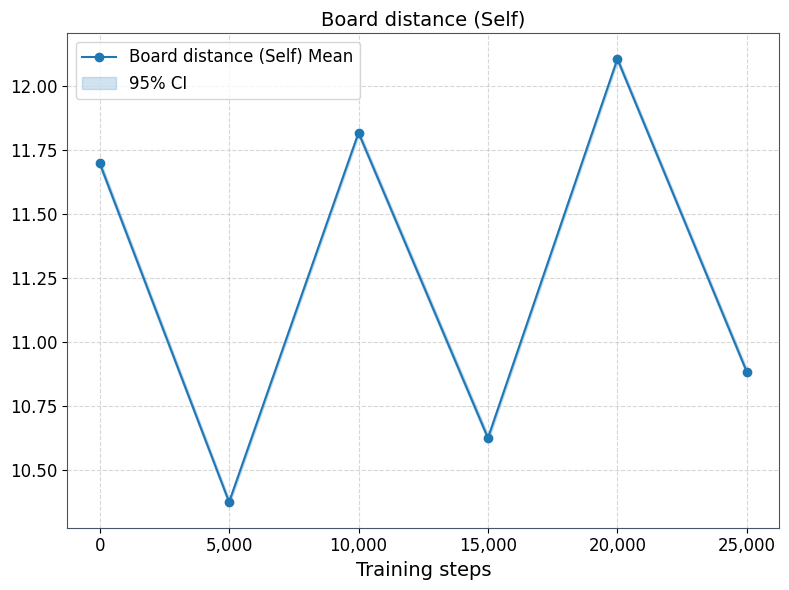

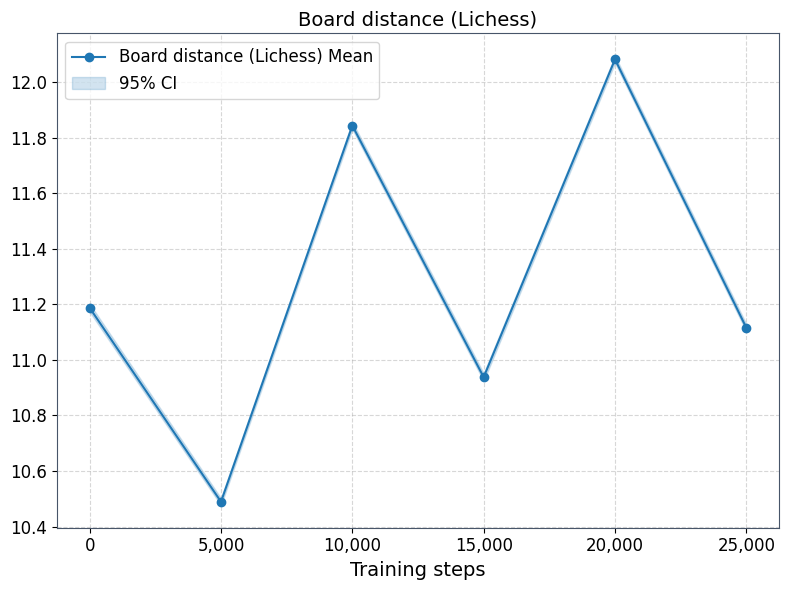

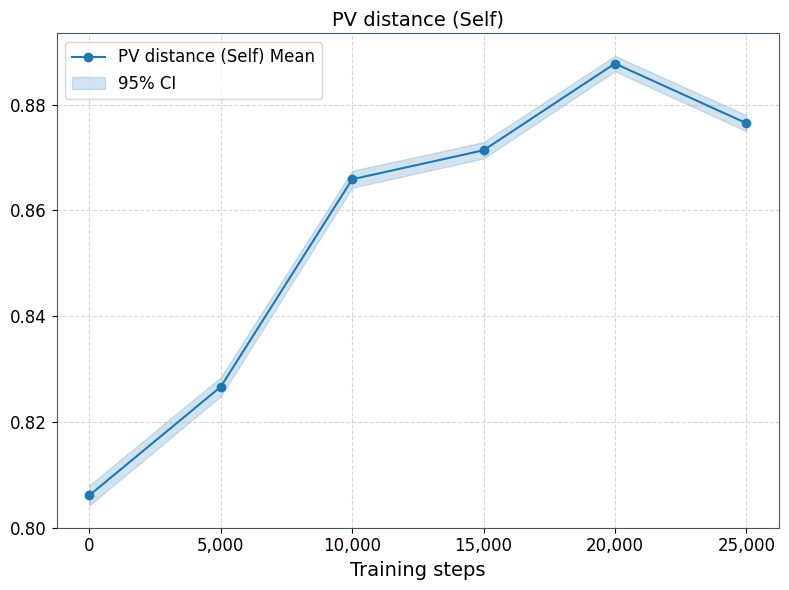

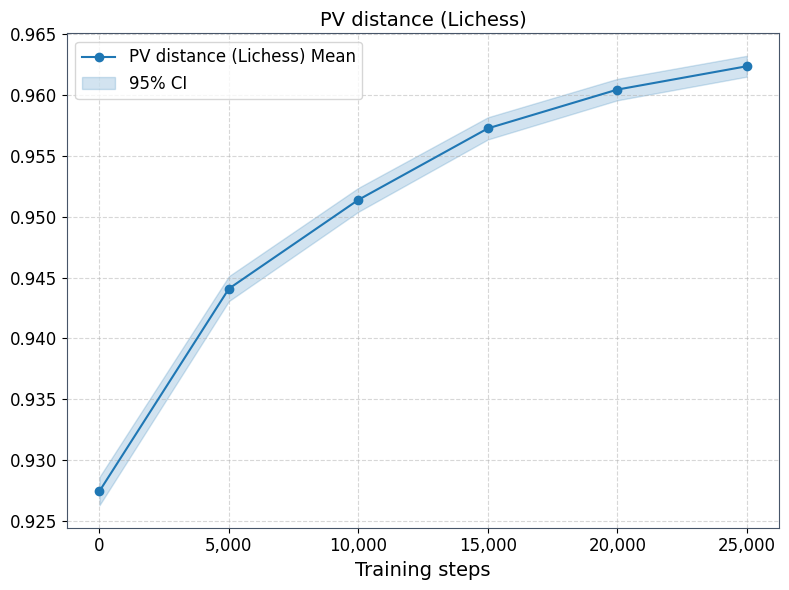

In [ ]:
# path = "Generate_positions/final_model/rl/training_progress/test_no_move_lastv2/distances.csv"
path = "Generate_positions/arxiv_paper/run22/distances.csv"
df = pd.read_csv(path)

metrics = {"Board distance (Self)": "self_distance_board", "Board distance (Lichess)": "lichess_distance_board", "PV distance (Self)": "self_distance_pv", "PV distance (Lichess)": "lichess_distance_pv"}
for name, metric in metrics.items():
    plt.figure(figsize=(8, 6))

    # Plotting
    plt.plot(df["checkpoint"], df[metric], marker="o", linestyle="-", c="tab:blue", label=f"{name} Mean")
    plt.fill_between(df["checkpoint"], df[metric] - df[metric + "_standard_error"], df[metric] + df[metric + "_standard_error"], alpha=0.2, color="tab:blue", label="95% CI")

    plt.xlabel("Training steps", fontsize=14)
    plt.title(name, fontsize=14)

    ax = plt.gca()
    ax.spines["top"].set_color("#475569")
    ax.spines["right"].set_color("#475569")
    ax.spines["left"].set_color("#475569")
    ax.spines["bottom"].set_color("#475569")
    ax.xaxis.set_major_locator(ticker.MultipleLocator(5_000))
    # ax.ticklabel_format(style="plain", axis="x")
    ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)

    # plt.legend(fontsize=12)
    plt.grid(which="both", linestyle='--', alpha=0.5)
    plt.legend(fontsize=12)
    plt.tight_layout()
    # plt.savefig(f"../Thesis/sections/figures/rl_training_progress/good_run_new_metrics/{metric.replace(' ', '_')}.pdf")
    # plt.savefig(f"./Generate_positions/arxiv_true/images/{metric.replace(' ', '_')}.pdf")
    plt.show()

In [8]:
# log_path = "../src/runs/rl/final_large_runs/final_thesis_experiments/full_diversity11"
log_path = Path("../src/runs/rl/final_large_runs/ownThemeDistribution/run22")
# df = tflog2pandas(log_path)
# df.index = range(len(df))
df = pd.read_csv(log_path / "log.csv")

In [9]:
df

,Components/legal_rate,step,Components/uniqueness_rate,Components/counter_intuitive_rate,Components/counter_intuitive_values,Components/counter_intuitive_values_given_unique,Components/counter_intuitive_rate_given_unique,Components/unique_and_counter_intuitive,Components/piece_counts,Components/themes_match_rate,...,Components/extra_theme_count,Loss/Total Loss,Loss/RL Grad Norm,Loss/KL divergence,Loss/Clips,Loss/learning_rate,Reward,Loss/Entropy,Components/counter_intuitive_values_max_given_unique_and_theme,Components/counter_intuitive_values_given_unique_and_theme
0,0.666667,0,0.020833,0.104167,0.022806,-0.000667,0.000000,0.000000,0.906250,0.000000,...,0.000000,-0.002110,0.926696,0.000000,0.001139,0.00001,-0.666667,4.449240,NaN,NaN
1,0.906250,1,0.020833,0.083333,0.018366,0.016000,0.000000,0.000000,0.919540,0.000000,...,0.000000,-0.001713,0.728421,0.009021,0.000163,0.00002,-0.187500,4.342617,NaN,NaN
2,0.958333,2,0.072917,0.072917,0.014083,0.008063,0.000000,0.000000,0.826087,0.428571,...,0.000000,-0.002031,0.387145,0.007072,0.000000,0.00003,-0.046713,4.637768,0.016000,0.008593
3,0.750000,3,0.114583,0.114583,0.028125,0.012606,0.090909,0.010417,0.888889,0.181818,...,0.000000,-0.002399,0.803245,0.020235,0.000326,0.00003,-0.500000,4.439022,0.016000,-0.034000
4,0.968750,4,0.156250,0.156250,0.031903,-0.013719,0.000000,0.000000,0.978495,0.333333,...,0.000000,-0.002069,0.300503,0.015709,0.000000,0.00003,-0.074491,4.540843,-0.039556,-0.075111
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26281,1.000000,26281,0.427083,0.093750,0.026875,0.007805,0.000000,0.000000,0.958333,0.365854,...,0.400000,-0.001820,0.217824,34.121643,0.000163,0.00003,0.058194,4.225061,0.020889,0.009244
26282,1.000000,26282,0.250000,0.093750,0.018569,-0.000667,0.000000,0.000000,0.937500,0.416667,...,0.200000,-0.001818,0.277699,29.692831,0.000000,0.00003,0.068472,4.283545,0.016000,-0.000667
26283,1.000000,26283,0.343750,0.052083,0.019833,0.010828,0.000000,0.000000,0.989583,0.818182,...,0.111111,-0.001916,0.273036,24.421494,0.000163,0.00003,0.118287,4.283397,0.068889,0.012148
26284,1.000000,26284,0.427083,0.062500,0.010569,0.010927,0.024390,0.010417,0.947917,0.682927,...,0.500000,-0.001851,0.241911,35.247658,0.000000,0.00003,0.228426,4.242554,0.046667,0.008762


In [10]:
def plotv1(col: pd.DataFrame, alpha=0.001, start=0, label=("", "95% CI")):
    ewm_mean = col.ewm(alpha=alpha).mean()
    ewm_std = col.ewm(alpha=alpha).std()
    
    ci_lower = ewm_mean - 1.96 * ewm_std
    ci_upper = ewm_mean + 1.96 * ewm_std
    
    plt.plot(col.index[start:], ewm_mean.iloc[start:], color="tab:blue", label=label[0])
    
    plt.fill_between(
        col.index[start:], 
        ci_lower.iloc[start:], 
        ci_upper.iloc[start:], 
        color="tab:blue", 
        alpha=0.2,
        label=label[1]
    )

def plotv2(col: pd.Series, alpha=0.001, start=0, label=("", "95% CI")):
    ewm_mean = col.ewm(alpha=alpha).mean()
    ewm_std = col.ewm(alpha=alpha).std()
    
    n_eff = (2 - alpha) / alpha    
    sem = ewm_std / np.sqrt(n_eff)
    ci_lower = ewm_mean - (1.96 * sem)
    ci_upper = ewm_mean + (1.96 * sem)
    
    plt.plot(col.index[start:], ewm_mean.iloc[start:], color="tab:blue", label=label[0])
    plt.fill_between(
        col.index[start:], 
        ci_lower.iloc[start:], 
        ci_upper.iloc[start:], 
        color="tab:blue", 
        alpha=0.2,
        label=label[1]
    )


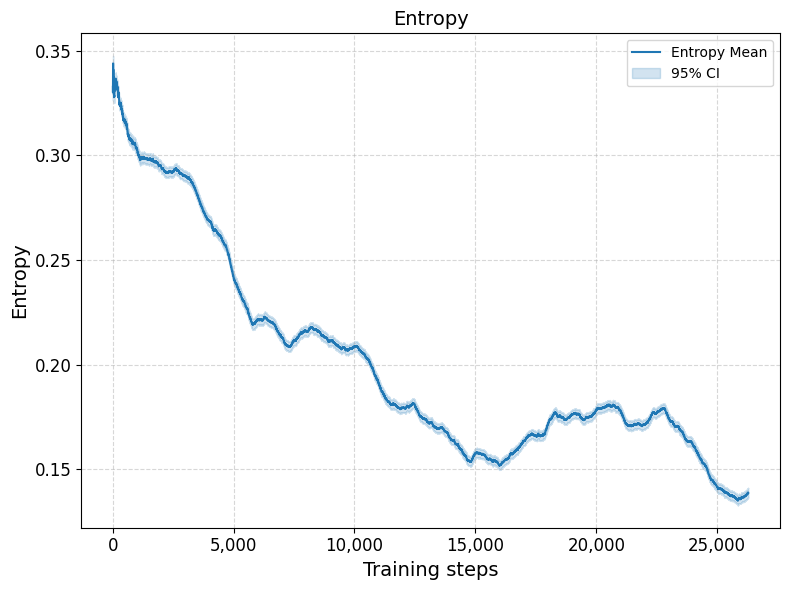

In [ ]:
plt.figure(figsize=(8, 6))
plt.title("Entropy", fontsize=14)
plotv2(df["Loss/Entropy"] - np.log(64), start=10, label=("Entropy Mean", "95% CI"))

ax = plt.gca()
ax.xaxis.set_major_locator(ticker.MultipleLocator(5000))
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.grid(which="both", linestyle='--', alpha=0.5)
plt.xlabel("Training steps", fontsize=14)
plt.ylabel("Entropy", fontsize=14)
plt.legend()
plt.tight_layout()
# plt.savefig(f"../Thesis/sections/figures/rl_training_progress/good_run/Entropy.pdf")
# plt.savefig(f"./Generate_positions/arxiv_true/images/entropy.pdf")
plt.show()

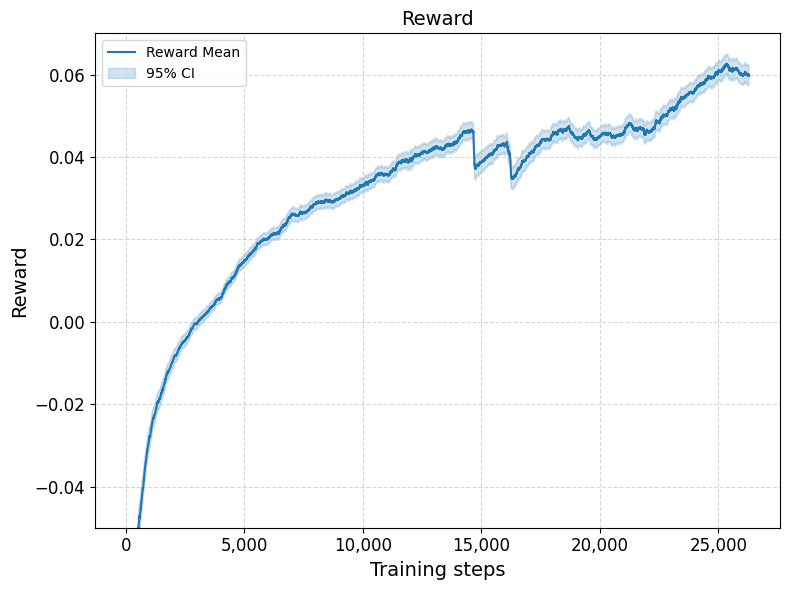

In [ ]:
plt.figure(figsize=(8, 6))
plt.title("Reward", fontsize=14)
plotv2(df["Reward"], start=10, label=("Reward Mean", "95% CI"))
plt.ylim((-0.05, 0.07))

ax = plt.gca()
ax.xaxis.set_major_locator(ticker.MultipleLocator(5000))
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.grid(which="both", linestyle='--', alpha=0.5)
plt.xlabel("Training steps", fontsize=14)
plt.ylabel("Reward", fontsize=14)
plt.legend()
plt.tight_layout()
# plt.savefig(f"../Thesis/sections/figures/rl_training_progress/good_run/Reward.pdf")
# plt.savefig(f"./Generate_positions/arxiv_true/images/reward.pdf")
plt.show()

In [62]:
df.columns

Index(['Components/legal_rate', 'step', 'Components/uniqueness_rate',
       'Components/counter_intuitive_rate',
       'Components/counter_intuitive_values',
       'Components/counter_intuitive_values_given_unique',
       'Components/counter_intuitive_rate_given_unique',
       'Components/unique_and_counter_intuitive', 'Components/piece_counts',
       'Components/themes_match_rate', 'Components/dist_inter_fen',
       'Components/dist_intra_fen', 'Components/dist_inter_pv',
       'Components/dist_intra_pv', 'Components/intra_dist',
       'Components/inter_dist', 'Components/all_dist',
       'Components/pass_diversity_filtering', 'Components/move_match_rate',
       'Components/cp_loss', 'Loss/Total Loss', 'Loss/RL Grad Norm',
       'Loss/KL divergence', 'Loss/Clips', 'Loss/learning_rate', 'Reward',
       'Loss/Entropy'],
      dtype='object')

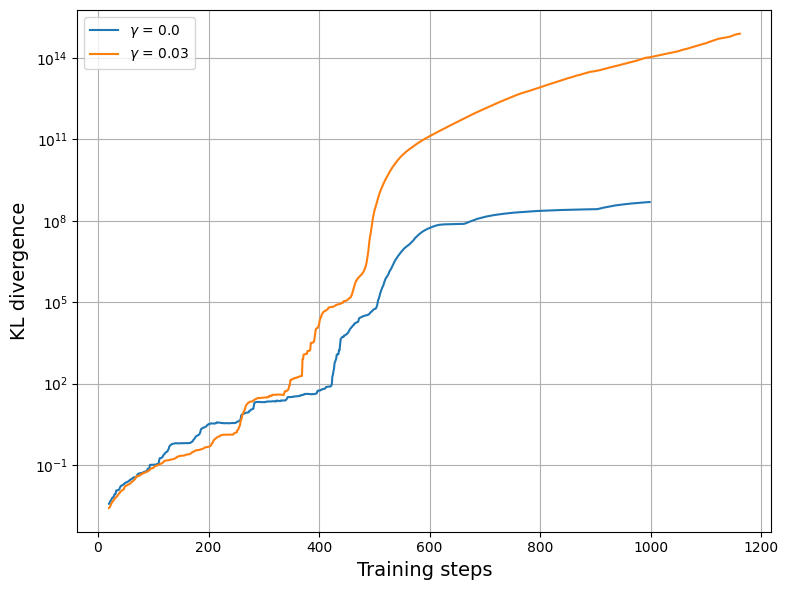

In [ ]:
plt.figure(figsize=(8, 6))
plot(df1["Loss/KL divergence"] / 81, start=20, alpha=0.01, label=r"$\gamma$ = 0.0")
plot(df2["Loss/KL divergence"] / 81, start=20, alpha=0.01, label=r"$\gamma$ = 0.03")
plt.xlabel("Training steps", fontsize=14)
plt.ylabel("KL divergence", fontsize=14)
# plt.title(col, fontsize=14)
# plt.legend(fontsize=14)
plt.grid(True)
plt.legend()
plt.yscale("log")
plt.tight_layout()

# plt.savefig(f"../Thesis/sections/figures/rl_training_progress/overfit/ESPO/kl_divergence.pdf")
plt.show()

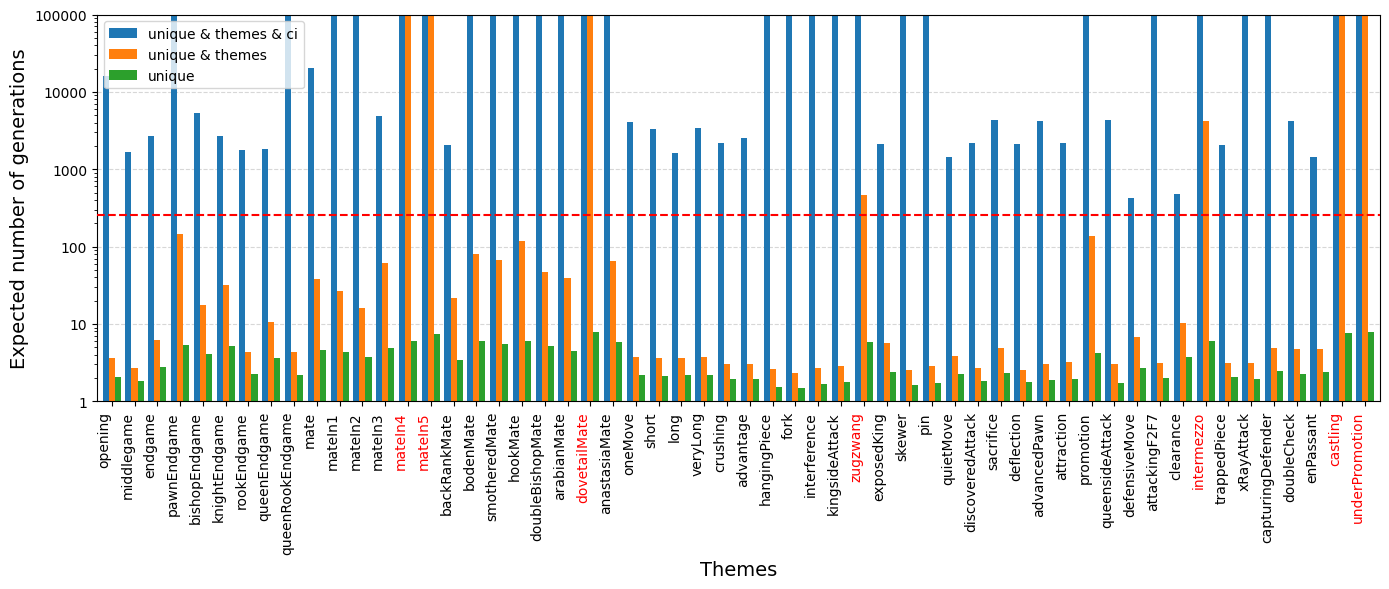

In [9]:
from rl.espo import state_of_game_tokens, endgames, is_mate, mate_lengths, types_of_mate, lengths, winnings, other


# path = Path("./Generate_positions/final_model/rl/full_diversity11/steps_experiment_own_theme_distribution/steps16v2.csv")
Path("./Generate_positions/final_model/rl/ownThemeDistribution/run10/positions_random.csv")
df = pd.read_csv(path)

unique_elements = [*state_of_game_tokens, *endgames, is_mate, *mate_lengths, *types_of_mate, *lengths, *winnings, *other]

items = {}
for item in unique_elements:
    if item == "equality":
        continue
    filtered_df = df[df["target_themes"].apply(lambda x: item in x)]
    
    eps = 1e-12
    items[item] = 1 / ((filtered_df["is_puzzle"] & filtered_df["counter_intuitive"] & filtered_df["themes_match"]).mean() + eps), 1 / ((filtered_df["is_puzzle"] & filtered_df["themes_match"]).mean() + eps), 1 / (filtered_df["is_puzzle"].mean() + eps)

df_plot = pd.DataFrame.from_dict(items, orient="index", columns=["unique & themes & ci", "unique & themes", "unique"])

ax = df_plot.plot(kind="bar", figsize=(14, 6), width=0.8)

plt.ylabel("Expected number of generations", fontsize=14)
plt.xlabel("Themes", fontsize=14)
plt.xticks(rotation=90, ha="right")
plt.yscale("log")
ax.set_axisbelow(True)
plt.grid(axis="y", zorder=0, linestyle='--', alpha=0.5)
plt.yticks([1, 10, 100, 1000, 10000, 100000])
plt.ylim((1, 100000))
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())

plt.axhline(y=256, color='red', linestyle='--', linewidth=1.5, zorder=3)

for tick_label in ax.get_xticklabels():
    theme_name = tick_label.get_text()
    if df_plot.loc[theme_name, "unique & themes"] > 256:
        tick_label.set_color("red")

plt.tight_layout()
plt.show()

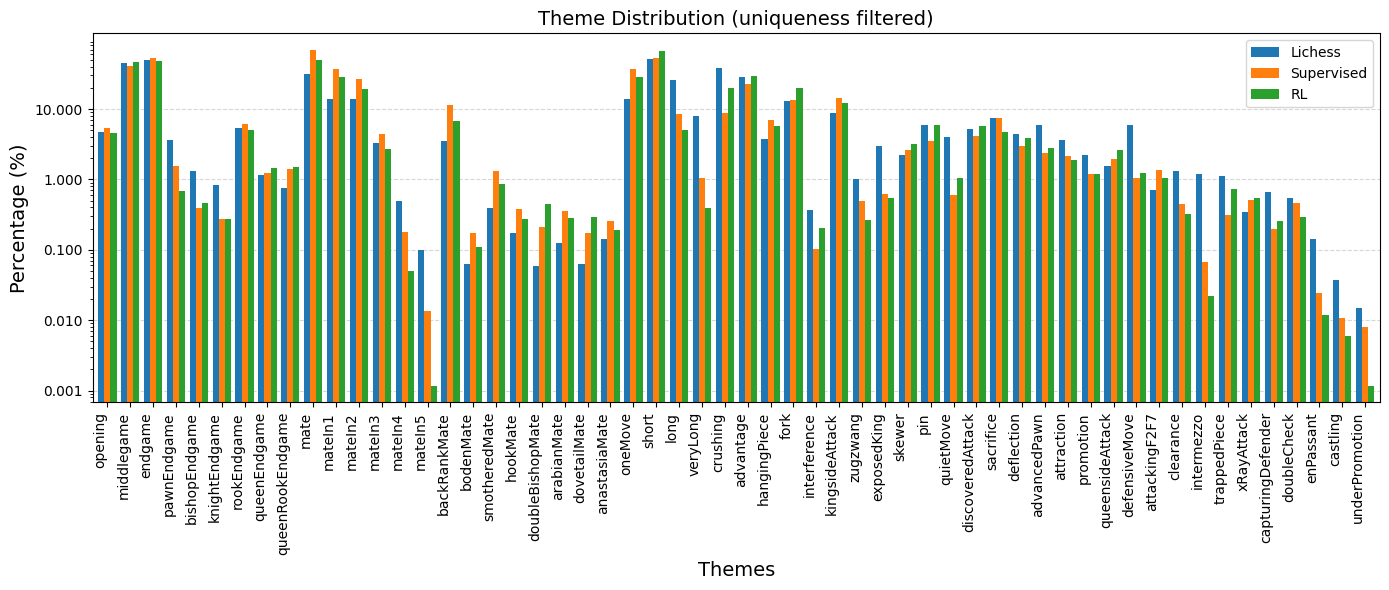

In [3]:
from rl.espo import state_of_game_tokens, endgames, is_mate, mate_lengths, types_of_mate, lengths, winnings, other


# path = Path("./Generate_positions/final_model/supervised/generated_positions/test_context_no_move_last.csv")
path = Path("./Generate_positions/arxiv_true/test_move.csv")
supervised = pd.read_csv(path)
supervised = supervised[supervised["is_puzzle"] & supervised["themes_match"]]
# path = Path("./Generate_positions/final_model/rl/full_diversity11_3500/test_context_no_move_lastv2.csv")
# path = Path("./Generate_positions/final_model/rl/full_diversity18/checkpoint_20000/test_context_no_move_last.csv")
# path = Path("./Generate_positions/final_model/rl/full_diversity11/steps_experiment_own_theme_distribution/steps16v2.csv")
path = Path("./Generate_positions/arxiv_true/run22/model_0020000.csv")
rl = pd.read_csv(path)
rl = rl[rl["is_puzzle"] & rl["themes_match"]]
# path = Path("./Generate_positions/Lichess/lichess_xidong_large.csv")
path = Path("./Generate_positions/arxiv_true/lichess.csv")
lichess = pd.read_csv(path)
lichess = lichess[lichess["is_puzzle"]]

supervised["actual_themes"] = supervised["actual_themes"].apply(ast.literal_eval)
rl["actual_themes"] = rl["actual_themes"].apply(ast.literal_eval)
lichess["Themes"] = lichess["Themes"].str.split()

unique_elements = [*state_of_game_tokens, *endgames, is_mate, *mate_lengths, *types_of_mate, *lengths, *winnings, *other]

items = {}
for item in unique_elements:
    if item == "equality":
        continue
    filtered_supervised = supervised[supervised["actual_themes"].apply(lambda x: item in x)]
    filtered_rl = rl[rl["actual_themes"].apply(lambda x: item in x)]
    filtered_lichess = lichess[lichess["Themes"].apply(lambda x: item in x)]
    
    # counter_intuitive = 100 * filtered_supervised["counter_intuitive"].mean()
    items[item] = 100 * len(filtered_lichess) / len(lichess), 100 * len(filtered_supervised) / len(supervised), 100 * len(filtered_rl) / len(rl)

df_plot = pd.DataFrame.from_dict(items, orient="index", columns=["Lichess", "Supervised", "RL"])
# df_plot = df_plot.sort_values(by=df_plot.index, ascending=False)
# df_plot = df_plot.sort_index(ascending=True)

# colors = ["#4C72B0", "#DD8452", "#55A868"]
# colors = ["#6B8EAD", "#E39B70", "#77AB7A"]
# df_plot.plot(kind="bar", figsize=(14, 6), width=0.8, color=colors)
df_plot.plot(kind="bar", figsize=(14, 6), width=0.8)
plt.title("Theme Distribution (uniqueness filtered)", fontsize=14)
plt.ylabel("Percentage (%)", fontsize=14)
plt.xlabel("Themes", fontsize=14)
plt.xticks(rotation=90, ha="right")
plt.yscale("log")
plt.gca().set_axisbelow(True)
plt.grid(axis="y", zorder=0, linestyle='--', alpha=0.5)
plt.yticks([10.0, 1.00, 0.10, 0.01, 0.001])
plt.gca().yaxis.set_major_formatter(ticker.ScalarFormatter())
plt.tight_layout()
# plt.savefig("../Thesis/sections/figures/other/theme_distribution.pdf")
plt.savefig("./Generate_positions/arxiv_true/images/theme_distribution.pdf")


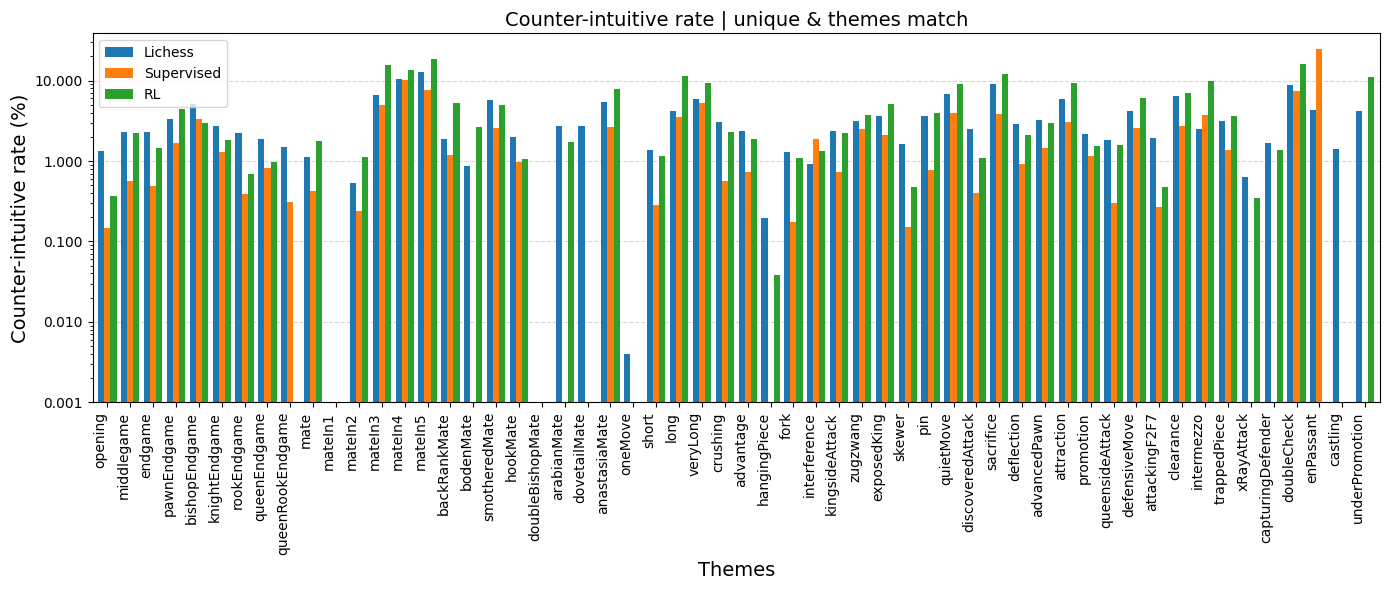

In [19]:
from rl.espo import state_of_game_tokens, endgames, is_mate, mate_lengths, types_of_mate, lengths, winnings, other


path = Path("./Generate_positions/final_model/supervised/generated_positions/test_context_no_move_last.csv")
supervised = pd.read_csv(path)
supervised = supervised[supervised["is_puzzle"] & supervised["themes_match"]]
path = Path("./Generate_positions/final_model/rl/full_diversity11_3500/test_context_no_move_lastv2.csv")
# path = Path("./Generate_positions/final_model/rl/full_diversity18/checkpoint_20000/test_context_no_move_last.csv")
rl = pd.read_csv(path)
rl = rl[rl["is_puzzle"] & rl["themes_match"]]
path = Path("./Generate_positions/Lichess/lichess_xidong_large.csv")
lichess = pd.read_csv(path)
lichess = lichess[lichess["is_puzzle"]]

supervised["actual_themes"] = supervised["actual_themes"].apply(ast.literal_eval)
rl["actual_themes"] = rl["actual_themes"].apply(ast.literal_eval)
lichess["Themes"] = lichess["Themes"].str.split()

unique_elements = [*state_of_game_tokens, *endgames, is_mate, *mate_lengths, *types_of_mate, *lengths, *winnings, *other]

items = {}
for item in unique_elements:
    if item == "equality":
        continue
    filtered_supervised = supervised[supervised["actual_themes"].apply(lambda x: item in x)]
    filtered_rl = rl[rl["actual_themes"].apply(lambda x: item in x)]
    filtered_lichess = lichess[lichess["Themes"].apply(lambda x: item in x)]
    
    # counter_intuitive = 100 * filtered_supervised["counter_intuitive"].mean()
    # items[item] = 100 * len(filtered_lichess) / len(lichess), 100 * len(filtered_supervised) / len(supervised), 100 * len(filtered_rl) / len(rl)
    items[item] = 100 * filtered_lichess["counter_intuitive"].mean(), 100 * filtered_supervised["counter_intuitive"].mean(), 100 * filtered_rl["counter_intuitive"].mean()

df_plot = pd.DataFrame.from_dict(items, orient="index", columns=["Lichess", "Supervised", "RL"])
# df_plot = df_plot.sort_values(by=df_plot.index, ascending=False)
# df_plot = df_plot.sort_index(ascending=True)

# colors = ["#4C72B0", "#DD8452", "#55A868"]
# colors = ["#6B8EAD", "#E39B70", "#77AB7A"]
# df_plot.plot(kind="bar", figsize=(14, 6), width=0.8, color=colors)
df_plot.plot(kind="bar", figsize=(14, 6), width=0.8)
plt.title("Counter-intuitive rate | unique & themes match", fontsize=14)
plt.ylabel("Counter-intuitive rate (%)", fontsize=14)
plt.xlabel("Themes", fontsize=14)
plt.xticks(rotation=90, ha="right")
plt.yscale("log")
plt.gca().set_axisbelow(True)
plt.grid(axis="y", zorder=0, linestyle='--', alpha=0.5)
plt.yticks([10.0, 1.00, 0.10, 0.01, 0.001])
plt.gca().yaxis.set_major_formatter(ticker.ScalarFormatter())
plt.tight_layout()
# plt.savefig("../Thesis/sections/figures/other/ci_distribution_over_themes.pdf")


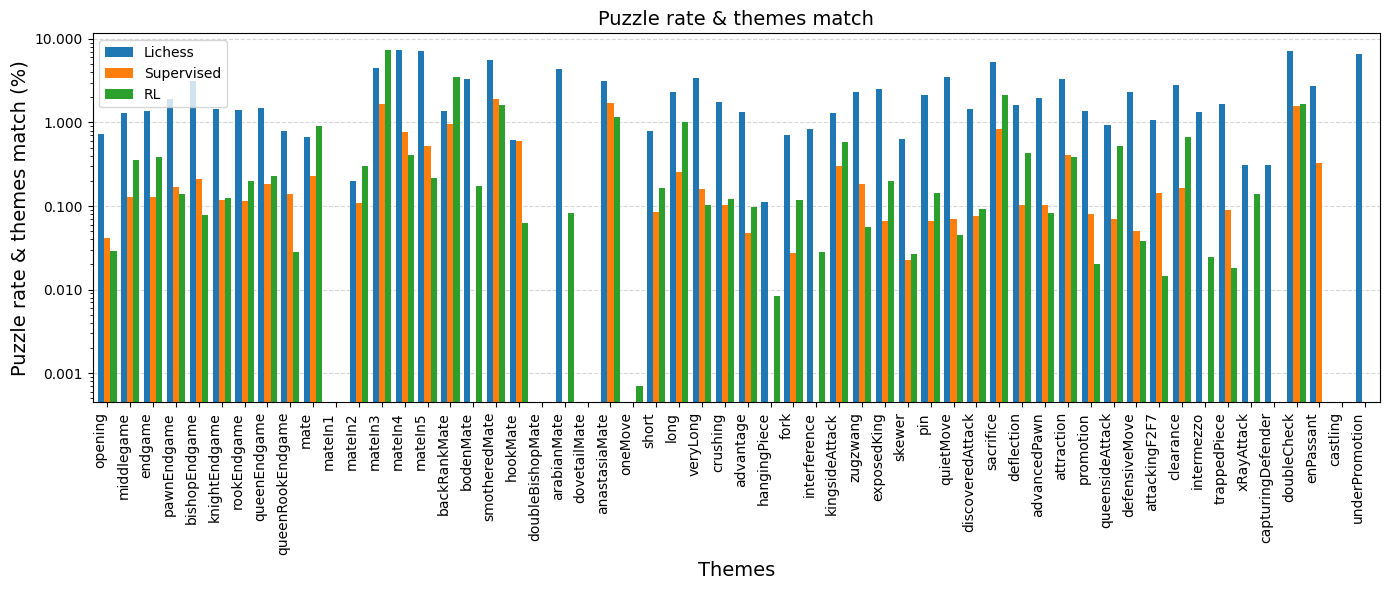

In [4]:
from rl.espo import state_of_game_tokens, endgames, is_mate, mate_lengths, types_of_mate, lengths, winnings, other


path = Path("./Generate_positions/final_model/supervised/v4/test_context_no_move_last.csv")
supervised = pd.read_csv(path)
# path = Path("./Generate_positions/final_model/rl/full_diversity11_3500/test_context_no_move_last.csv")
path = Path("./Generate_positions/final_model/rl/full_diversity18/checkpoint_20000/test_context_no_move_last.csv")
rl = pd.read_csv(path)
path = Path("./Generate_positions/Lichess/lichess_first_time_move_found_division_50.csv")
lichess = pd.read_csv(path)

supervised["target_themes"] = supervised["target_themes"].apply(ast.literal_eval)
rl["target_themes"] = rl["target_themes"].apply(ast.literal_eval)
lichess["target_themes"] = lichess["target_themes"].apply(ast.literal_eval)

unique_elements = [*state_of_game_tokens, *endgames, is_mate, *mate_lengths, *types_of_mate, *lengths, *winnings, *other]

items = {}
for item in unique_elements:
    if item == "equality":
        continue
    filtered_supervised = supervised[supervised["target_themes"].apply(lambda x: item in x)]
    filtered_rl = rl[rl["target_themes"].apply(lambda x: item in x)]
    filtered_lichess = lichess[lichess["target_themes"].apply(lambda x: item in x)]
    
    items[item] = 100 * (filtered_lichess["is_puzzle"] & filtered_lichess["counter_intuitive"]).mean(), 100 * (filtered_supervised["is_puzzle"] & filtered_supervised["counter_intuitive"] & filtered_supervised["themes_match"]).mean(), 100 * (filtered_rl["is_puzzle"] & filtered_rl["counter_intuitive"] & filtered_rl["themes_match"]).mean()

df_plot = pd.DataFrame.from_dict(items, orient="index", columns=["Lichess", "Supervised", "RL"])
# df_plot = df_plot.sort_values(by=df_plot.index, ascending=False)
# df_plot = df_plot.sort_index(ascending=True)

# colors = ["#4C72B0", "#DD8452", "#55A868"]
# colors = ["#6B8EAD", "#E39B70", "#77AB7A"]
# df_plot.plot(kind="bar", figsize=(14, 6), width=0.8, color=colors)
df_plot.plot(kind="bar", figsize=(14, 6), width=0.8)
plt.title("Puzzle rate & themes match", fontsize=14)
plt.ylabel("Puzzle rate & themes match (%)", fontsize=14)
plt.xlabel("Themes", fontsize=14)
plt.xticks(rotation=90, ha="right")
plt.yscale("log")
plt.gca().set_axisbelow(True)
plt.grid(axis="y", zorder=0, linestyle='--', alpha=0.5)
plt.yticks([10.0, 1.00, 0.10, 0.01, 0.001])
plt.gca().yaxis.set_major_formatter(ticker.ScalarFormatter())
plt.tight_layout()
# plt.savefig("../Thesis/sections/figures/other/puzzle_rate_distribution_over_themes.pdf")
